In [2]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [3]:
df_sess_force     = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, 'force.session.success.tsv'), sep='\t')
dat_sess_fmri     = df_sess_force[df_sess_force.session.isin([3, 9, 23])].reset_index(drop=True)
trained_fder      = dat_sess_fmri[dat_sess_fmri.chord=='trained'].reset_index(drop=True)
untrained_fder    = dat_sess_fmri[dat_sess_fmri.chord=='untrained'].reset_index(drop=True)
diff_fder         = trained_fder.copy()
diff_fder['Diff'] = untrained_fder.force_der - trained_fder.force_der

In [4]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'nanmean'
activation       = pd.read_csv(os.path.join(gl.baseDir, f'glm{glm}', 'ROI.activation.tsv'), sep='\t')
activation       = activation.groupby(['chord', 'session', 'sn', 'regionname', 'Hem']).mean(numeric_only=True).reset_index()
trained_act      = activation[activation.chord=='trained'].reset_index(drop=True)
untrained_act    = activation[activation.chord=='untrained'].reset_index(drop=True)
diff_act         = trained_act.copy()
diff_act['Diff'] = untrained_act[stat] - trained_act[stat]

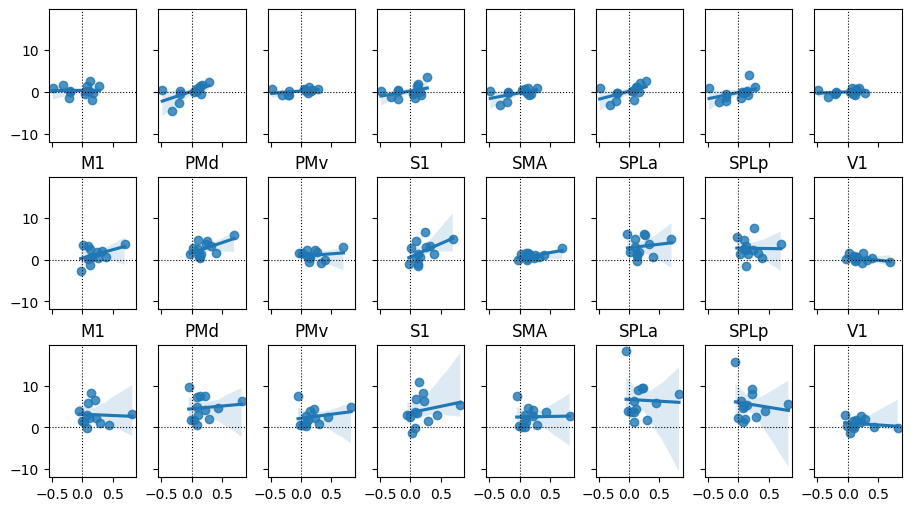

In [5]:
session   = diff_act.session.unique()
rois      = diff_act.regionname.unique()
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = diff_act[(diff_act.Hem==H) & (diff_act.regionname==roi) & (diff_act.session==sess)].Diff.to_numpy()
                x    = diff_fder[diff_fder.session==sess].Diff.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s>0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')


In [6]:
records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
        })
intercepts = pd.DataFrame(records)
intercepts

,regionname,session,intercept,ci_low,ci_high
0,M1,3,0.294606,-0.501406,1.090619
1,M1,9,0.345349,-1.310939,2.001637
2,M1,23,3.150966,1.036908,5.265023
3,PMd,3,0.074335,-0.886235,1.034906
4,PMd,9,1.558651,0.239928,2.877374
5,PMd,23,4.434347,2.105432,6.763262
6,PMv,3,0.180716,-0.191864,0.553296
7,PMv,9,0.804646,-0.258825,1.868118
8,PMv,23,2.173669,0.440557,3.906780
9,S1,3,0.174046,-0.662484,1.010576


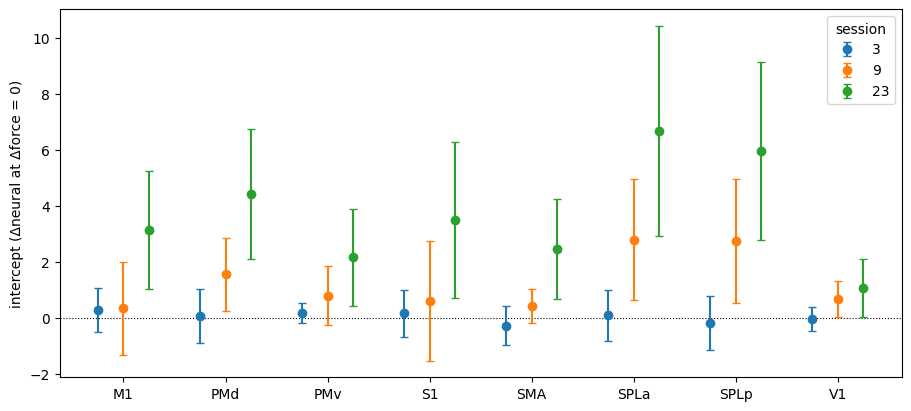

In [7]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.axhline(0, color='k', lw=.8, ls=':')

rois     = intercepts.regionname.unique()
sessions = intercepts.session.unique()
offsets  = np.linspace(-.25, .25, len(sessions))

for off, sess in zip(offsets, sessions):
        g = intercepts[intercepts.session == sess]
        ax.errorbar(np.arange(len(rois)) + off, g.intercept,
                    yerr=[g.intercept - g.ci_low, g.ci_high - g.intercept],
                    fmt='o', capsize=3, label=sess)

ax.set_xticks(range(len(rois)), rois)
ax.set_ylabel('intercept (Δneural at Δforce = 0)')
ax.legend(title='session')

In [17]:
G3 = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.within_session.3.glm3.L.PMd.npy'))
D3 = pcm.G_to_dist(G3)
G9 = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.within_session.9.glm3.L.PMd.npy'))
D9 = pcm.G_to_dist(G9)
G23 = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.within_session.23.glm3.L.PMd.npy'))
D23 = pcm.G_to_dist(G23)

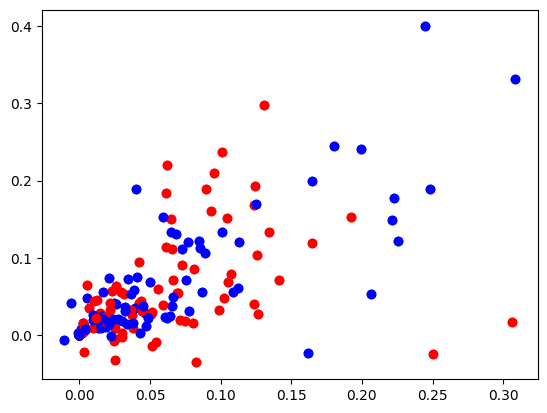

In [18]:
for i in range(13):
    plt.scatter(D3[i, :4, :4], D9[i, :4, :4], color='red')
    plt.scatter(D3[i, 4:, 4:], D9[i, 4:, 4:], color='blue')

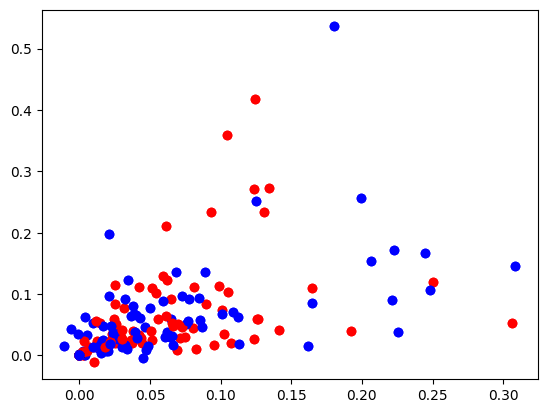

In [19]:
for i in range(13):
    plt.scatter(D3[i, :4, :4], D23[i, :4, :4], color='red')
    plt.scatter(D3[i, 4:, 4:], D23[i, 4:, 4:], color='blue')